In [1]:
import math
import matplotlib.pyplot as plt
from multiprocessing import Pool
import numpy as np
import pandas as pd
import statistics

normal_dist = statistics.NormalDist(0., 1.)

On considère l'EDP de pricing suivante du modèle Black-Scholes en log-espace:

$$
    \partial_t u(t, x) + \frac{\sigma^2}{2} \partial^2_{x x} u(t, x) + (r - \frac{\sigma^2}{2}) \partial_x u(t, x) - r u(t, x) = 0, \quad \forall t \in [0, T], \forall x \in \mathcal{D} \quad \mathrm{(*)}
$$
avec la condition terminale:
$$
    u(T, x) = (e^x - K)^+, \quad \forall x \in \mathcal{D}
$$

où $\mathcal{D} \subset \mathbb{R}$ est un domaine qu'on précisera par la suite. En particulier, ce sera un intervalle fermé borné, ce qui nous donne donc en particulier un problème aux limites dont les conditions aux bords seront également précisées dans ce qui suit.

## Localisation (déjà faite au TP1)

On rappelle l'EDS de Black-Scholes en log-espace (*i.e.* $\exp(s_t)$ suivra un Black-Scholes standard):
$$
    \mathrm{d} s_t = (r - \frac{\sigma^2}{2}) \mathrm{d} t + \sigma \mathrm{d} W_t
$$

Soient $\lambda > 0$ et $t \in ]0; T]$. Notons $\bar{s}(t) := s_0 + (r - \frac{\sigma^2}{2}) t$.

On cherchera $\ell_t > 0$ tel que:
$$
    \mathbb{Q}(\bar{s}(t) - \ell_t \leq s_t \leq \bar{s}(t) + \ell_t) = 1 - \lambda \quad \mathrm{(**)}
$$

Il faut savoir retrouver que $\ell_t = \sigma \sqrt{t} F_{N(0,1)}^{-1}(1 - \frac{\lambda}{2})$, où $F_{N(0,1)}^{-1}$ est l'inverse de la fonction de répartition de la loi normale centrée réduite.

L'équation $\mathrm{(**)}$ nous dit alors que $s_t$ sera dans l'intervalle $[\bar{s}(t) - \ell_t; \bar{s}(t) + \ell_t]$ avec une probabilité $1 - \lambda$.

1) Montrer que si on choisit $L_T = \max_{t \in [0;T]} \ell_t$ (c'est quoi?), alors on aura l'inclusion suivante:
$$
    [\bar{s}(t) - \ell_t; \bar{s}(t) + \ell_t] \subset \left[s_0 - |r - \frac{\sigma^2}{2}| T - L_T; s_0 + |r - \frac{\sigma^2}{2}| T + L_T\right]
$$

3) Que peut-on dire alors sur la probabilité suivante: $$\mathbb{Q}(|s_t - s_0| \leq |r - \frac{\sigma^2}{2}| T + L_T)$$

4) Conclure avec un choix raisonnable pour tronquer $\mathcal{D}$.

On considère par la suite que $\mathcal{D} = [s_{\text{min}}; s_{\text{max}}]$ avec $s_{\text{min}}$ et $s_{\text{max}}$ deux bornes que vous avez déterminées ici.

Ecrire une fonction `compute_s_min` qui prend en entrée $\lambda$, $s_0$, $r$, $\sigma$, $T$ et qui retourne le $s_{\text{min}}$ choisi. Faire pareil avec `compute_s_max` pour $s_{\text{max}}$.

In [2]:
def compute_s_min(lam, s0, r, sigma, T):
    return s0 - abs(r - 0.5 * sigma**2) * T - sigma * math.sqrt(T) * normal_dist.inv_cdf(1 - 0.5 * lam)

def compute_s_max(lam, s0, r, sigma, T):
    return s0 + abs(r - 0.5 * sigma**2) * T + sigma * math.sqrt(T) * normal_dist.inv_cdf(1 - 0.5 * lam)

Vérifiez par exemple pour $s_0 = 0$, $r = 0.02$, $\sigma = 0.25$, $T = 1$ et $\lambda = 0.01$ que vous avez bien $\mathbb{Q}(s_{\text{min}} \leq s_t \leq s_{\text{max}}) \geq 1 - \lambda$ pour différents $t$.

In [3]:
def proba_test(t, s0, r, sigma, T, smin, smax):
    tmp_normal_dist = statistics.NormalDist(r - 0.5 * sigma**2, sigma * math.sqrt(t))
    return tmp_normal_dist.cdf(smax) - tmp_normal_dist.cdf(smin)

In [4]:
tmp_s_min = compute_s_min(0.01, 0., 0.02, 0.25, 1.)
tmp_s_max = compute_s_max(0.01, 0., 0.02, 0.25, 1.)
for t in (0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.):
    print(proba_test(t, 0., 0.02, 0.25, 1., tmp_s_min, tmp_s_max) > 0.99)

True
True
True
True
True
True
True
True
True
True
True


## Discrétisation

On considère deux grilles $0 =: t_0 < t_1 < \dots < t_n := T$ et $s_{\text{min}} =: s^{(0)} < s^{(1)} < \dots < s^{(m)} := s_{\text{max}}$ à pas constants respectifs $h$ et $\delta$, *i.e.*:
$$
    t_i = i h \quad\text{et}\quad s^{(j)} = s_{\text{min}} + j \delta, \quad \forall i \in \{0, \dots, n\}, \forall j \in \{0, \dots, m\}
$$

On cherche à construire une solution approchée $(u_{i,j})_{\substack{0\leq i\leq n \\ 0\leq j\leq m}}$ de la solution de l'EDP $\mathrm{(*)}$ aux points de notre grille 2D, *i.e* $u_{i,j} \approx u(t_i, s^{(j)})$.

On va faire cela via un schéma de **Crank-Nicholson**, qui s'écrit dans notre cas (il faut savoir le retrouver) pour tout $i\in\{0, \dots, n-1\}, j\in\{1, \dots, m-1\}$:
$$
\left\{
\begin{aligned}
    \frac{h}{4 \delta}\left(r - (\frac{1}{\delta} + \frac{1}{2}) \sigma^2\right) u_{i, j-1} + \left(1 + \frac{1}{2}(r + \frac{\sigma^2}{\delta^2}) h\right) u_{i, j} - \frac{h}{4 \delta}\left(r + (\frac{1}{\delta} - \frac{1}{2}) \sigma^2\right) u_{i, j+1} = \tilde{u}_{i + 1, j}\\
    \tilde{u}_{i+1,j} = \frac{h}{4 \delta}\left(-r + (\frac{1}{\delta} + \frac{1}{2}) \sigma^2\right) u_{i+1, j-1} + \left(1 - \frac{1}{2}(r + \frac{\sigma^2}{\delta^2}) h\right) u_{i+1, j} + \frac{h}{4 \delta}\left(r + (\frac{1}{\delta} - \frac{1}{2}) \sigma^2\right) u_{i+1, j+1}
\end{aligned}
\right.
$$

ou plus simplement
$$
\left\{
\begin{aligned}
    \alpha u_{i, j-1} + \beta u_{i, j} + \gamma u_{i, j+1} &= \tilde{u}_{i + 1, j} ,\quad \forall i\in\{0, \dots, n-1\}\\
    \tilde{u}_{i+1,j} &= a u_{i+1, j-1} + b u_{i+1, j} + c u_{i+1, j+1}
\end{aligned}
\right., \forall j\in\{1, \dots, m-1\} \quad\mathrm{(***)}
$$

où
$$
    \left\{
        \begin{aligned}
            \alpha &= \frac{h}{4 \delta}\left(r - (\frac{1}{\delta} + \frac{1}{2}) \sigma^2\right) \\
            \beta &= 1 + \frac{1}{2}(r + \frac{\sigma^2}{\delta^2}) h \\
            \gamma &= - \frac{h}{4 \delta}\left(r + (\frac{1}{\delta} - \frac{1}{2}) \sigma^2\right)
        \end{aligned}
    \right.
$$
et

$$
    \left\{
        \begin{aligned}
            a &= \frac{h}{4 \delta}\left(-r + (\frac{1}{\delta} + \frac{1}{2}) \sigma^2\right) \\
            b &= 1 - \frac{1}{2}(r + \frac{\sigma^2}{\delta^2}) h \\
            c &= \frac{h}{4 \delta}\left(r + (\frac{1}{\delta} - \frac{1}{2}) \sigma^2\right)
        \end{aligned}
    \right.
$$

Comparé au TP1 et TP2, cette fois-ci on s'est retrouvé avec à la fois une étape explicite et une autre implicite.

L'indice temporel $n$ correspond à la date de maturité $T$, à laquelle on connait la solution, donc on peut aussi rajouter la condition terminale sous forme discrétisée:
$$
    u_{n, j} = (e^{s^{(j)}} - K)^+, \forall j \in \{0, \dots, m\}
$$

Maintenant pour les indices $j=0$ et $j=m$ aux instants antérieurs, il nous faut des conditions aux limites.

On va considérer que pour $x$ très grand, on a $u(t,x) \approx e^x - e^{-r (T - t)} K$ (call très dans la monnaie), et que pour $x$ très petit on a $u(t,x) = 0$ (call très en dehors de la monnaie). Cela nous donne naturellement donc ces deux conditions aux bords:

$$
    \mathrm{(****)}\quad \left\{
        \begin{aligned}
            u_{i, 0} &= 0\\
            u_{i, m} &= e^{s^{(m)}} - e^{-r (T - i h)} K\\
        \end{aligned}
    \right. \quad,\forall i \in \{0, \dots, n - 1\}
$$

Si on groupe $\mathrm{(***)}$ et $\mathrm{(****)}$ ensemble, cela nous donne sous forme matricielle:
$$A^{\mathrm{impl}} U^{(i)} = \varphi_i\left(A^{\mathrm{expl}} U^{(i + 1)}\right)$$

où:

* $U^{(i)} := \left[u_{i,0}; u_{i,1}; \dots; u_{i, m}\right]^{\top}$;
* $A^{\mathrm{impl}}$ est la matrice $(m+1)\times(m+1)$ tridiagonale: $A^{\mathrm{impl}} = \mathrm{tridiag}(\tilde{\alpha}, \tilde{\beta}, \tilde{\gamma})$;
* $A^{\mathrm{expl}}$ est la matrice $(m+1)\times(m+1)$ tridiagonale: $A^{\mathrm{expl}} = \mathrm{tridiag}(a, b, c)$;
* $\varphi_i$ est une fonction qui, appliquée à un vecteur $x$, laisse les composantes inchangées à la sortie sauf la première et la dernière, qui deviendront respectivement $0$ et $e^{s^{(m)}} - e^{-r (T - i h)} K$.

avec $\tilde{\alpha}$, $\tilde{\beta}$, $\tilde{\gamma}$ des vecteurs tels que:
$$
\left\{
\begin{aligned}
\tilde{\alpha} &= [\underbrace{\alpha, \dots, \alpha}_{m - 1\text{ fois}}, 0]^{\top}\\
\tilde{\beta} &= [1, \underbrace{\beta, \dots, \beta}_{m - 1\text{ fois}}, 1]^{\top}\\
\tilde{\gamma} &= [0, \underbrace{\gamma, \dots, \gamma}_{m - 1\text{ fois}}]^{\top}
\end{aligned}
\right.
$$

1) Ecrire une fonction `implicit_matrix` qui prend en entrée $r$, $\sigma$, $h$, $\delta$, $m$ et qui retourne la matrice tridiagonale $A^{\mathrm{impl}}$ ci-dessus.

In [5]:
def implicit_matrix(r, sigma, h, delta, m):
    sigma_sq = sigma**2
    a = 0.25 * h * (r - (0.5 + 1. / delta) * sigma_sq) / delta
    b = 1 + 0.5 * (r + sigma_sq / delta**2) * h
    c = - 0.25 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    a_tilde = np.r_[np.repeat(a, m - 1), 0.]
    b_tilde = np.r_[1., np.repeat(b, m - 1), 1.]
    c_tilde = np.r_[0., np.repeat(c, m - 1)]
    return np.diag(a_tilde, -1) + np.diag(b_tilde) + np.diag(c_tilde, 1)

1) Ecrire une fonction `explicit_matrix` qui prend en entrée $r$, $\sigma$, $h$, $\delta$, $m$ et qui retourne la matrice tridiagonale $A^{\mathrm{expl}}$ ci-dessus.

In [6]:
def explicit_matrix(r, sigma, h, delta, m):
    sigma_sq = sigma**2
    a = 0.25 * h * (-r + (0.5 + 1. / delta) * sigma_sq) / delta
    b = 1 - 0.5 * (r + sigma_sq / delta**2) * h
    c = 0.25 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    return np.diag(np.repeat(a, m), -1) + np.diag(np.repeat(b, m + 1)) + np.diag(np.repeat(c, m), 1)

2) Ecrire une fonction `boundary_cond_transform` qui prend en entrée $i$, $r$, $h$, $T$, $s_{max}$, $K$ ainsi qu'un vecteur $x$ arbitraire et qui retourne le vecteur $\varphi\left(x\right)$ ci-dessus. Vous pouvez écraser $x$ (auquel cas ce n'est pas la peine de retourner quoi que ce soit).

In [7]:
def boundary_cond_transform(i, r, h, T, s_max, K, x):
    x[0] = 0.
    x[-1] = math.exp(s_max) - math.exp(-r * (T - i * h)) * K

3) Comme dans les précédents TPs, combinez vos deux fonctions pour faire un solveur qui itère sur les pas de temps $i$, en commençant avec $i = n$, jusqu'à arriver à calculer $U^{(0)}$. Votre solveur sera appelable via une fonction `cranknicholson_scheme_price` qui prend en entrée $r$, $\sigma$, $T$, $K$, $s_0$, $\lambda$, $m$, $n$ ainsi qu'un argument booléen `midpoint` et qui donne en sortie le prix approché en $(t_0, s_0)$ si `midpoint == True` et qui retourne le vecteur $U^{(0)}$ ainsi que la grille $\{s^{(i)}\}_{0 \leq i \leq m}$ sinon.

In [8]:
def cranknicholson_scheme_price(r, sigma, T, K, s0, lam, m, n, midpoint):
    s_min = compute_s_min(lam, s0, r, sigma, T)
    s_max = compute_s_max(lam, s0, r, sigma, T)
    delta = (s_max - s_min) / (m - 1)
    h = 1. / (n - 1)
    K = 1.
    A_impl = implicit_matrix(r, sigma, h, delta, m - 1)
    A_expl = explicit_matrix(r, sigma, h, delta, m - 1)
    s_grid = np.linspace(s_min, s_max, num=m)
    u = np.maximum(np.exp(s_grid) - K, 0.)
    for i in range(n - 1):
        u = A_expl @ u
        boundary_cond_transform(n-i-2, r, h, T, s_max, K, u)
        u = np.linalg.solve(A_impl, u)
    if midpoint:
        return float(u[m // 2])
    else:
        return u, s_grid

4) Ecrivez une fonction `closed_formula_price` qui prend en entrée $r$, $\sigma$, $T$, $K$, $s_0$ et qui implémente la formule fermée de Black-Scholes pour le prix du call européen vanille considéré. On rappelle que ce prix s'écrit $$S_0\cdot F_{N(0,1)}(d_1) - K \cdot e^{-rT} \cdot F_{N(0,1)}(d_2)$$

où $S_0 = \exp(s_0)$ et

$$d_1 = \frac{\ln\left(\frac{S_0}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

Comparez ce que vous obtenez avec cette formule fermée et ce que donne le schéma d'Euler implicite avec ce que vous avez implémenté dans la question 3. Utilisez comme paramètres $\alpha = 0.001$, $s_0 = 0$, $r = 0.02$, $\sigma = 0.25$, $T = 1$, $K = 1$, $m = 513$ et $n = 128$.

In [9]:
def closed_formula_price(r, sigma, T, K, s0):
    sigma_sqrtT = sigma * math.sqrt(T)
    d1 = (s0 - math.log(K) + (r + 0.5 * sigma**2) * T) / sigma_sqrtT
    d2 = d1 - sigma_sqrtT
    return math.exp(s0) * normal_dist.cdf(d1) - K * math.exp(-r * T) * normal_dist.cdf(d2)

In [10]:
closed_formula_price(0.02, 0.25, 1., 1., 0.)

0.10870558490557586

In [11]:
cranknicholson_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, 513, 128, True)

0.10870454837897006

Beaucoup plus précis qu'avant!

5) Tracez un graphe du prix à la date $0$ en fonction de $s$ en utilisant ce que vous obtenez avec `cranknicholson_scheme_price` en utilisant les mêmes paramètres qu'avant mais en donnant `False` pour l'argument booléen.

In [12]:
prices, s_grid = cranknicholson_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, 513, 128, False)

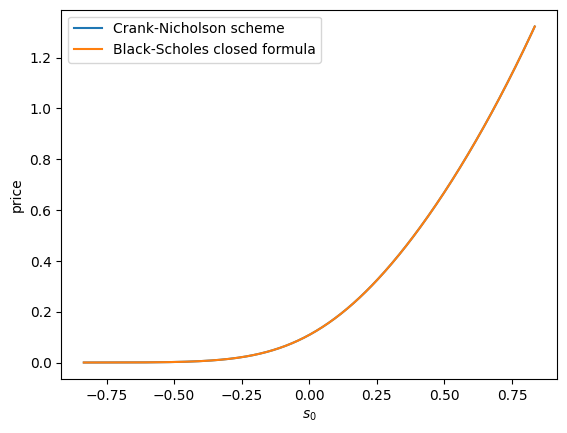

In [13]:
plt.plot(s_grid, prices, label='Crank-Nicholson scheme')
plt.plot(s_grid, [closed_formula_price(0.02, 0.25, 1., 1., s0) for s0 in s_grid], label='Black-Scholes closed formula')
plt.xlabel('$s_0$')
plt.ylabel('price')
plt.legend();

L'abscisse est en log-espace, donc ce ne sont pas vraiment des niveaux du sous-jacent, mais les logs de ceux-ci. On va changer d'échelle en appliquant une `exp` sur les abscisses pour avoir nos graphes en fonction du niveau du sous-jacent:

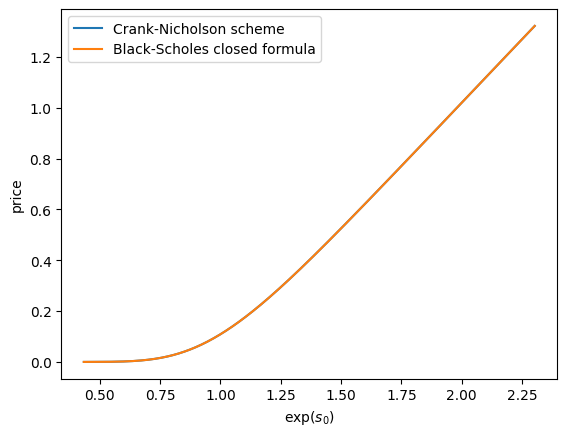

In [14]:
exp_s_grid = np.exp(s_grid)
plt.plot(exp_s_grid, prices, label='Crank-Nicholson scheme')
plt.plot(exp_s_grid, [closed_formula_price(0.02, 0.25, 1., 1., s0) for s0 in s_grid], label='Black-Scholes closed formula')
plt.xlabel(r'$\exp(s_0)$')
plt.ylabel('price')
plt.legend();

## Stabilité du schéma numérique

En utilisant les mêmes paramètres que la question 4 de la section précédente, définissez une fonction `compute_err` qui pour un couple `mn` (ie un tuple de taille 2 où le premier élément joue le rôle de `m` et le second celui de `n`) calcule l'écart en valeur absolue entre le prix par formule fermée (considéré comme notre référence) et le prix approché correspondant obtenu par le schéma de Crank-Nicholson.

Calculez ensuite cette erreur pour toutes les valeurs possibles de $m$ et $n$ dans l'ensemble $\left\{2^4, 2^5, 2^6, 2^7, 2^8, 2^9\right\}$ (on a de nouveau réduit par rapport au TP1 car les résolutions de systèmes sont lentes).

**Petit conseil**: comme ce sera long à faire en séquentiel, il vaut mieux paralléliser ce calcul exhaustif. Pensez à utiliser `Pool` du module `multiprocessing` (voir l'introduction dans https://docs.python.org/3/library/multiprocessing.html) et utilisez comme nombre de processus un nombre autour du nombre de coeurs que vous avez sur votre PC. Si `multiprocessing` ne marche pas sur votre installation, une alternative est `concurrent.futures`, voir: https://docs.python.org/3/library/concurrent.futures.html (dans ce cas en particulier vous allez devoir utiliser un `ProcessPoolExecutor`).

En général, si vous avez une fonction `f` qui à une entrée `x` associe `f(x)`, et que vous voulez évaluer `f` en chaque point d'une collection `L` de façon parallèle, vous pouvez le faire avec l'une des deux méthodes suivantes:
* avec `multiprocessing` (`from multiprocessing import Pool`):
```
L = ... # une liste d'inputs sur lesquels on souhaite paralléliser f

def f(x):
    # fait quelque chose et retourne un resultat

with Pool(8) as p: # 8 est à remplacer par le nombre de coeurs que vous avez, ou moins si vous voulez paralléliser encore moins
    resultats = p.map(f, L)

# maintenant pour tout i, resultats[i] va être égal à f(L[i]), et tous ces résultats auront été calculés en parallèle
```
* avec `concurrent.futures` (`from concurrent.futures import ProcessPoolExecutor`):
```
L = ... # une liste d'inputs sur lesquels on souhaite paralléliser f

def f(x):
    # fait quelque chose et retourne un resultat

with ProcessPoolExecutor(max_workers=8) as executor: # 8 est à remplacer par le nombre de coeurs que vous avez, ou moins si vous voulez paralléliser encore moins
    resultats = list(executor.map(f, L))
```

Si aucune des deux ne marche (très dépendant de l'OS...), essayez de mettre le bloc `with` au sein d'un `if __name__ == '__main__'`comme suit:
```
if __name__ == '__main__':
    with Pool(8) as p:
        resultats = p.map(f, L)
```

Pensez à représenter le résultat obtenu sous forme d'une matrice d'erreurs $6 \times 6$ dans une jolie `DataFrame` avec comme index et colonnes les puissances de 2 ci-dessus.

In [15]:
r = 0.02
sigma = 0.25
T = 1.
K = 1.
s0 = 0.
alpha = 0.001

candidates = [2**i for i in range(4, 10)]
ref_price = closed_formula_price(0.02, 0.25, 1., 1., 0.)

def compute_err(mn):
    m, n = mn
    return abs(cranknicholson_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, m, n, True) - ref_price)

with Pool(8) as p:
    candidate_pairs = [(m, n) for m in candidates for n in candidates]
    errors = p.map(compute_err, candidate_pairs)

Vous ne devrez normalement plus avoir de warnings liés à des overflows ou des NaNs, c'est déjà bon signe...

In [16]:
errors_df = pd.DataFrame(
    index=candidates,
    columns=candidates,
    data=np.array(errors).reshape(6, 6)
)

errors_df

,16,32,64,128,256,512
16,0.035764,0.035756,0.035754,0.035754,0.035754,0.035754
32,0.016451,0.016442,0.016440,0.016439,0.016439,0.016439
64,0.007909,0.007898,0.007896,0.007896,0.007896,0.007896
128,0.003990,0.003877,0.003875,0.003875,0.003874,0.003875
256,0.002451,0.001970,0.001924,0.001923,0.001923,0.001923
512,0.001947,0.001203,0.000983,0.000962,0.000962,0.000962


Conclusion?

Super, encore un schéma inconditionnelement convergent! Pour l'instant les tests dans cette table ne permettent pas encore de voir l'intérêt de ce schéma. Il faut tester pour des valeurs de $m$ et $n$ plus grandes. Or avec des ressources limitées on arrivera difficilement à le faire sans attendre des heures... D'où l'intérêt d'optimiser un peu plus nos algorithmes dans ce qui suit :-)

## (avancé) Faire (beaucoup) plus vite

In [17]:
import numba as nb

@nb.njit
def tridiag_mult_inplace(a, b, c, x):
    size = x.size
    x_0 = x[0]
    x_1 = x[1]
    x[0] = b * x_0 + c * x_1
    for i in range(1, size - 1):
        x_2 = x[i + 1]
        x[i] = a * x_0 + b * x_1 + c * x_2
        x_0 = x_1
        x_1 = x_2
    x[size - 1] = a * x_0 + b * x_1

@nb.njit
def thomas_inv(a, b, c, y):
    # résout le système tridiag(a, b, c) @ x = y d'inconnue x via l'algorithme de Thomas
    # dans cette version on écrase directement y
    size = y.size
    scratch = np.zeros(size - 1)
    
    scratch[0] = c / b
    y[0] = y[0] / b

    for i in range(1, size - 1):
        scratch[i] = c / (b - a * scratch[i - 1])
    
    for i in range(1, size):
        y[i] = (y[i] - a * y[i - 1]) / (b - a * scratch[i - 1])
    
    for i in range(size - 2, -1, -1):
        y[i] = y[i] - scratch[i] * y[i + 1]

In [18]:
def fast_cranknicholson_scheme_price(r, sigma, T, K, s0, lam, m, n, midpoint):
    s_min = compute_s_min(lam, s0, r, sigma, T)
    s_max = compute_s_max(lam, s0, r, sigma, T)
    delta = (s_max - s_min) / (m - 1)
    h = 1. / (n - 1)
    K = 1.
    sigma_sq = sigma**2
    alpha = 0.25 * h * (r - (0.5 + 1. / delta) * sigma_sq) / delta
    beta = 1 + 0.5 * (r + sigma_sq / delta**2) * h
    gamma = - 0.25 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    a = 0.25 * h * (-r + (0.5 + 1. / delta) * sigma_sq) / delta
    b = 1 - 0.5 * (r + sigma_sq / delta**2) * h
    c = 0.25 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    s_grid = np.linspace(s_min, s_max, num=m)
    u = np.maximum(np.exp(s_grid) - K, 0.)
    for i in range(n - 1):
        tridiag_mult_inplace(a, b, c, u)
        boundary_cond_transform(i, r, h, T, s_max, K, u)
        thomas_inv(alpha, beta, gamma, u)
    if midpoint:
        return float(u[m // 2])
    else:
        return u, s_grid

In [19]:
%%timeit
cranknicholson_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, 512, 32, True)

220 ms ± 23.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [20]:
%%timeit
fast_cranknicholson_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, 512, 32, True)

731 μs ± 63.4 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


Encore une fois un speedup impressionnant de plus de x200!

Comme le pricing est désormais plus rapide, on va se permettre d'explorer plus de valeurs pour $m$ et $n$ du tableau précédent:

In [21]:
new_candidates = [2**i for i in range(4, 15)]

def compute_err(mn):
    m, n = mn
    return abs(fast_cranknicholson_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, m, n, True) - ref_price)

with Pool(8) as p:
    new_candidate_pairs = [(m, n) for m in new_candidates for n in new_candidates]
    new_errors = p.map(compute_err, new_candidate_pairs)

In [22]:
tmp_size = len(new_candidates)

new_errors_df = pd.DataFrame(
    index=new_candidates,
    columns=new_candidates,
    data=np.array(new_errors).reshape(tmp_size, tmp_size)
)

new_errors_df

,16,32,64,128,256,512,1024,2048,4096,8192,16384
16,0.035487,0.035603,0.035674,0.035713,0.035734,0.035744,0.035749,0.035752,0.035753,0.035754,0.035754
32,0.016086,0.016208,0.016306,0.016368,0.016402,0.016420,0.016430,0.016435,0.016437,0.016438,0.016439
64,0.007370,0.007470,0.007604,0.007719,0.007798,0.007844,0.007869,0.007883,0.007889,0.007893,0.007894
128,0.003308,0.003224,0.003321,0.003464,0.003606,0.003717,0.003788,0.003829,0.003851,0.003863,0.003869
256,0.001699,0.001185,0.001160,0.001237,0.001365,0.001520,0.001664,0.001773,0.001841,0.001880,0.001901
512,0.001167,0.000366,0.000125,0.000118,0.000169,0.000264,0.000403,0.000562,0.000707,0.000815,0.000882
1024,0.000992,0.000094,0.000290,0.000406,0.000408,0.000378,0.000317,0.000216,0.000075,0.000087,0.000232
2048,0.000930,0.000005,0.000427,0.000615,0.000672,0.000673,0.000656,0.000622,0.000558,0.000456,0.000312
4096,0.000905,0.000027,0.000472,0.000684,0.000777,0.000805,0.000805,0.000797,0.000778,0.000743,0.000678
8192,0.000894,0.000040,0.000488,0.000707,0.000812,0.000858,0.000872,0.000872,0.000868,0.000858,0.000839


Vous remarquerez que pour $m$ suffisamment grand, la convergence en $n$ est plus rapide qu'avec le schéma implicite.